# Startup Investment Outcome — Exploratory Data Analysis

**Dataset:** `assets/investments_VC.csv` | 54,294 startups | 40 features
**Goal:** Understand the data, investigate missing values, and document preprocessing decisions.

Every section ends with a **→ Preprocessing Decision** box that maps directly to a sklearn Pipeline step in `03_Preprocessing.ipynb`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

In [ ]:
df = pd.read_csv('/content/investments_VC.csv')
df.columns = df.columns.str.strip()

# Fix funding_total_usd: commas, hyphens, cast to float
df['funding_total_usd'] = (
    df['funding_total_usd'].astype(str).str.strip()
    .str.replace(',', '', regex=False)
    .replace({'-': np.nan, 'nan': np.nan, '': np.nan})
)
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

# Fix market: strip pipes and whitespace
df['market'] = df['market'].astype(str).str.strip().str.strip('|').str.strip()
df['market'] = df['market'].replace({'nan': np.nan, '': np.nan})

print(f"Shape: {df.shape}")
df.head(3)

Shape: (54294, 39)


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,NY,New York City,New York,1.0,2012-06-01,2012-06,2012-Q2,2012.0,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,4000000.0,operating,USA,CA,Los Angeles,Los Angeles,2.0,NaN,NaN,NaN,NaN,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,40000.0,operating,EST,NaN,Tallinn,Tallinn,1.0,2012-10-26,2012-10,2012-Q4,2012.0,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Target Variable

Null status: 6,170 (11.4%)
status
operating    41829
acquired      3692
closed        2603
Name: count, dtype: int64


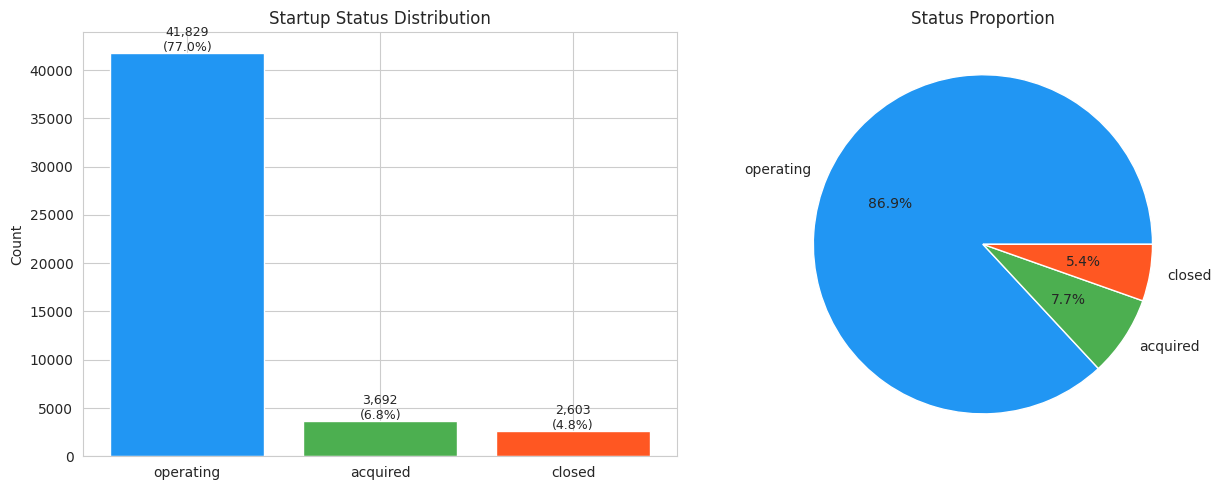

In [ ]:
status_counts = df['status'].value_counts()
print(f"Null status: {df['status'].isna().sum():,} ({df['status'].isna().mean()*100:.1f}%)")
print(status_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2196F3', '#4CAF50', '#FF5722']
axes[0].bar(status_counts.index, status_counts.values, color=colors)
axes[0].set_title('Startup Status Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Status Proportion')
plt.tight_layout()
plt.show()

**→ Preprocessing Decision:** Drop all rows where `status` is null (11.4%).
No label = cannot be used for training or evaluation.
Applied to the full dataset **before** the train/val/test split.

## 2. Missing Values Overview

                      null_count  null_pct
state_code                 24133      44.4
founded_quarter            15812      29.1
founded_month              15812      29.1
founded_year               15812      29.1
founded_at                 15740      29.0
funding_total_usd          13387      24.7
city                       10972      20.2
region                     10129      18.7
country_code               10129      18.7
market                      8824      16.3
category_list               8817      16.2
homepage_url                8305      15.3
status                      6170      11.4
permalink                   4856       8.9
name                        4857       8.9
funding_rounds              4856       8.9
first_funding_at            4856       8.9
last_funding_at             4856       8.9
seed                        4856       8.9
venture                     4856       8.9
equity_crowdfunding         4856       8.9
undisclosed                 4856       8.9
convertible

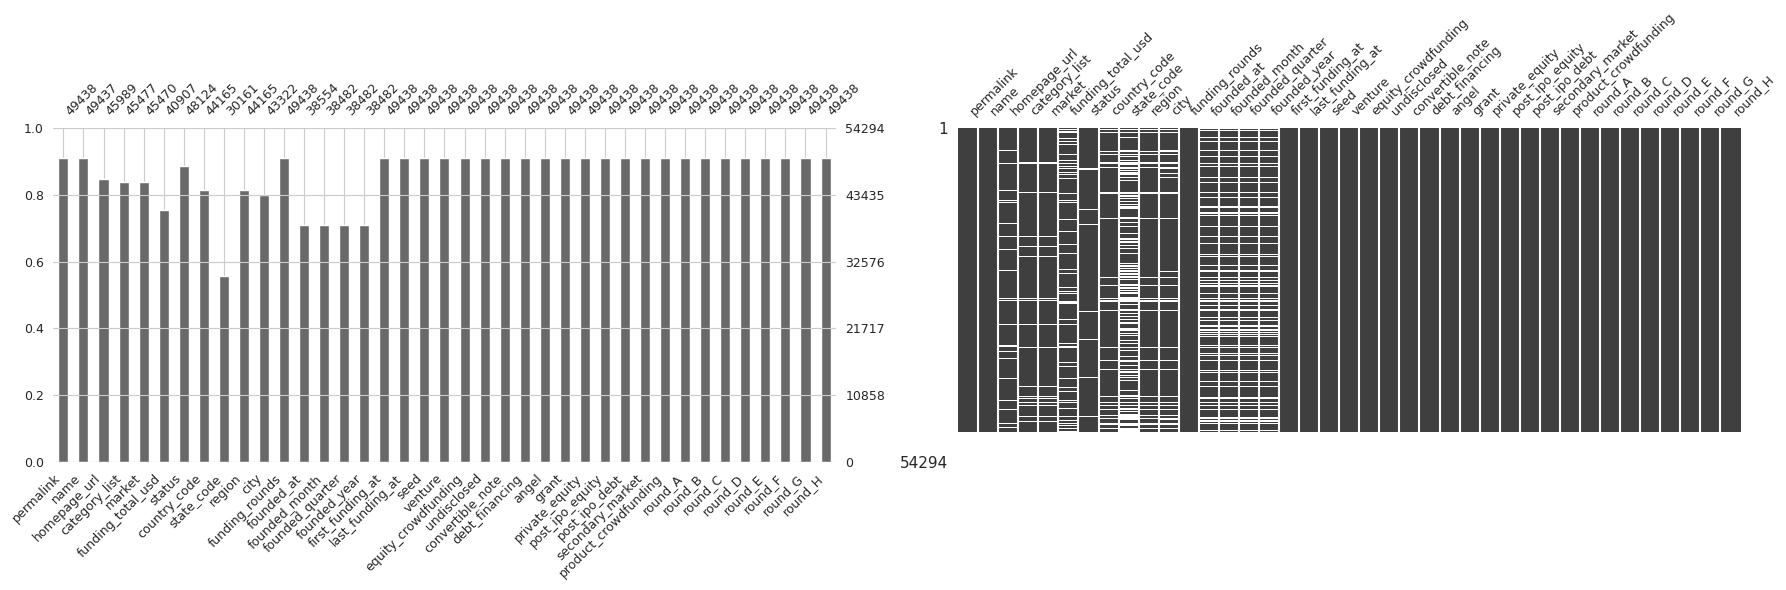

In [ ]:
null_df = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('null_pct', ascending=False)
print(null_df[null_df['null_count'] > 0].to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
msno.bar(df, ax=axes[0], fontsize=9)
msno.matrix(df, ax=axes[1], fontsize=9)
plt.tight_layout()
plt.show()

## 3. Missing Values Research

### 3.1 `funding_total_usd` — 24.6% null

% of each status with null funding_total_usd:
           Has funding  Null funding
status                              
acquired          87.2          12.8
closed            82.9          17.1
operating         82.3          17.7


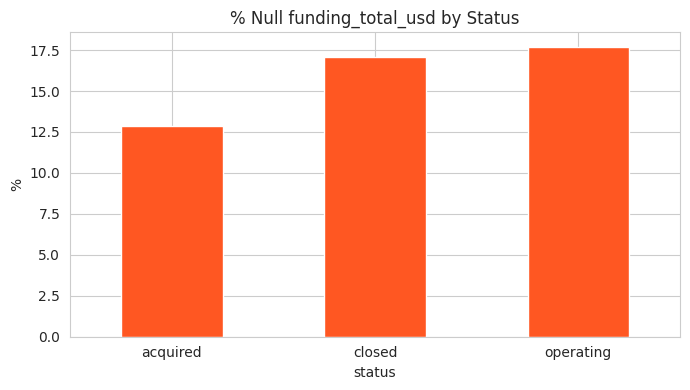

In [ ]:
df_s = df[df['status'].notna()].copy()
df_s['funding_null'] = df_s['funding_total_usd'].isna()
ct = pd.crosstab(df_s['status'], df_s['funding_null'], normalize='index') * 100
ct.columns = ['Has funding', 'Null funding']
print("% of each status with null funding_total_usd:")
print(ct.round(1))
ct['Null funding'].plot(kind='bar', color='#FF5722', figsize=(7, 4),
                        title='% Null funding_total_usd by Status')
plt.ylabel('%'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

=== Does rounds_sum ≈ funding_total_usd? ===
Rows with both values:       40,907
Exact match (diff < $1):     28,149  (68.8%)
Within 1% difference:        28,154  (68.8%)

Median absolute difference:  $0
Mean absolute difference:    $6,361,628

=== Null funding_total_usd: 13,387 rows ===
  rounds_sum > 0  → CAN impute:    0  (0.0%)
  rounds_sum == 0 → truly unknown: 13,387  (100.0%)


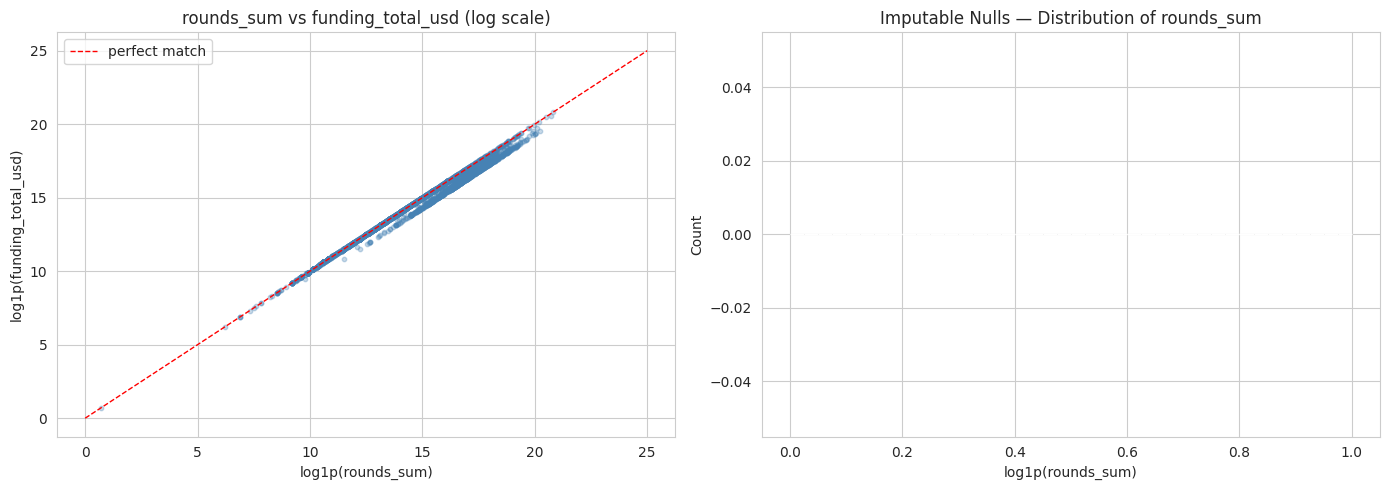


=== Conclusion ===
funding_total_usd ≈ sum of rounds for most rows (check scatter above).
0 null rows can be filled with rounds_sum.
13,387 null rows have zero funding info → will be dropped.


In [ ]:
all_round_cols = ['seed', 'venture', 'angel', 'round_A', 'round_B', 'round_C',
                  'round_D', 'round_E', 'round_F', 'round_G', 'round_H',
                  'equity_crowdfunding', 'undisclosed', 'convertible_note',
                  'debt_financing', 'grant', 'private_equity',
                  'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

df['rounds_sum'] = df[all_round_cols].sum(axis=1)

# ── 1. How well does rounds_sum match funding_total_usd? ─────────────────────
has_both = df[df['funding_total_usd'].notna() & (df['rounds_sum'] > 0)].copy()
has_both['diff'] = (has_both['funding_total_usd'] - has_both['rounds_sum']).abs()
has_both['pct_diff'] = has_both['diff'] / has_both['funding_total_usd'].replace(0, np.nan) * 100

exact       = (has_both['diff'] < 1).sum()
within_1pct = (has_both['pct_diff'] < 1).sum()
total_both  = len(has_both)

print("=== Does rounds_sum ≈ funding_total_usd? ===")
print(f"Rows with both values:       {total_both:,}")
print(f"Exact match (diff < $1):     {exact:,}  ({exact/total_both:.1%})")
print(f"Within 1% difference:        {within_1pct:,}  ({within_1pct/total_both:.1%})")
print(f"\nMedian absolute difference:  ${has_both['diff'].median():,.0f}")
print(f"Mean absolute difference:    ${has_both['diff'].mean():,.0f}")

# ── 2. Null analysis ──────────────────────────────────────────────────────────
null_total = df['funding_total_usd'].isna()
print(f"\n=== Null funding_total_usd: {null_total.sum():,} rows ===")

null_df = df[null_total].copy()
null_df['rounds_sum'] = null_df[all_round_cols].sum(axis=1)

can_impute = (null_df['rounds_sum'] > 0).sum()
truly_zero = (null_df['rounds_sum'] == 0).sum()

print(f"  rounds_sum > 0  → CAN impute:    {can_impute:,}  ({can_impute/null_total.sum():.1%})")
print(f"  rounds_sum == 0 → truly unknown: {truly_zero:,}  ({truly_zero/null_total.sum():.1%})")

# ── 3. Scatter: rounds_sum vs funding_total_usd ───────────────────────────────
sample = has_both.sample(min(3000, len(has_both)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(np.log1p(sample['rounds_sum']),
                np.log1p(sample['funding_total_usd']),
                alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 25], [0, 25], 'r--', linewidth=1, label='perfect match')
axes[0].set_xlabel('log1p(rounds_sum)')
axes[0].set_ylabel('log1p(funding_total_usd)')
axes[0].set_title('rounds_sum vs funding_total_usd (log scale)')
axes[0].legend()

axes[1].hist(np.log1p(null_df[null_df['rounds_sum'] > 0]['rounds_sum']),
             bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Imputable Nulls — Distribution of rounds_sum')
axes[1].set_xlabel('log1p(rounds_sum)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# ── 4. Conclusion ─────────────────────────────────────────────────────────────
print("\n=== Conclusion ===")
print(f"funding_total_usd ≈ sum of rounds for most rows (check scatter above).")
print(f"{can_impute:,} null rows can be filled with rounds_sum.")
print(f"{truly_zero:,} null rows have zero funding info → will be dropped.")

In [ ]:
df_test = df.copy()
df_test['rounds_sum'] = df_test[all_round_cols].fillna(0).sum(axis=1)
before = df_test['funding_total_usd'].isna().sum()
mask = df_test['funding_total_usd'].isna() & (df_test['rounds_sum'] > 0)
df_test.loc[mask, 'funding_total_usd'] = df_test.loc[mask, 'rounds_sum']
after   = df_test['funding_total_usd'].isna().sum()
to_drop = df_test[df_test['funding_total_usd'].isna()].shape[0]
print(f"Null funding_total_usd BEFORE imputation:        {before:,}")
print(f"Null funding_total_usd AFTER  impute from rounds: {after:,}")
print(f"Rows to DROP (rounds_sum=0, no info at all):     {to_drop:,}")

Null funding_total_usd BEFORE imputation:        13,387
Null funding_total_usd AFTER  impute from rounds: 13,387
Rows to DROP (rounds_sum=0, no info at all):     13,387


**→ Preprocessing Decision:**
1. Compute `rounds_sum` = sum of all individual funding source + round columns
2. Where `funding_total_usd` is null **and** `rounds_sum > 0` → impute from `rounds_sum`
3. Where `funding_total_usd` is still null **and** `rounds_sum = 0` → **DROP** (no funding data)

Applied to the full dataset before the split. Saved to `data/investments_VC_clean.csv`.

### 3.2 Date Columns — `founded_year`, `founded_month`, `founded_quarter` (29% null)

In [ ]:
date_cols = ['founded_year','founded_month','founded_quarter','founded_at']
print("Null counts:"); print(df[date_cols].isnull().sum())
all_three = df[['founded_year','founded_month','founded_quarter']].isnull().all(axis=1).sum()
any_one   = df[['founded_year','founded_month','founded_quarter']].isnull().any(axis=1).sum()
print(f"\nAll three null together: {all_three:,}")
print(f"Any one null:            {any_one:,}")
print(f"→ They are {'ALWAYS' if all_three==any_one else 'NOT always'} null together.")

Null counts:
founded_year       15812
founded_month      15812
founded_quarter    15812
founded_at         15740
dtype: int64

All three null together: 15,812
Any one null:            15,812
→ They are ALWAYS null together.


In [ ]:
df_d = df[df['founded_at'].notna() & df['founded_year'].notna()].copy()
df_d['founded_at_dt'] = pd.to_datetime(df_d['founded_at'], errors='coerce')
df_d['year_parsed']    = df_d['founded_at_dt'].dt.year
df_d['month_parsed']   = df_d['founded_at_dt'].dt.month
df_d['quarter_parsed'] = df_d['founded_at_dt'].dt.quarter

# Convert existing columns to numeric before comparing (they may be StringDtype)
founded_year_num    = pd.to_numeric(df_d['founded_year'].astype(object),    errors='coerce')
founded_month_num   = pd.to_numeric(df_d['founded_month'].astype(object),   errors='coerce')
founded_quarter_num = pd.to_numeric(df_d['founded_quarter'].astype(object), errors='coerce')

print(f"year  match: {(df_d['year_parsed'] == founded_year_num).mean()*100:.1f}%")
print(f"month match: {(df_d['month_parsed'] == founded_month_num).mean()*100:.1f}%")
print(f"qtr   match: {(df_d['quarter_parsed'] == founded_quarter_num).mean()*100:.1f}%")
print("\n→ founded_at IS the source — we can extract year/month/quarter directly from it.")

year  match: 100.0%
month match: 0.0%
qtr   match: 0.0%

→ founded_at IS the source — we can extract year/month/quarter directly from it.


In [ ]:
df_fill = df.copy()
df_fill['_at_dt'] = pd.to_datetime(df_fill['founded_at'], errors='coerce')

# pandas 2.x: StringDtype columns reject numeric .loc assignment
# → convert via object first, fill from founded_at, assign numpy array to bypass restriction
df_fill['founded_year']    = pd.to_numeric(df_fill['founded_year'].astype(object),    errors='coerce').fillna(df_fill['_at_dt'].dt.year).values
df_fill['founded_month']   = pd.to_numeric(df_fill['founded_month'].astype(object),   errors='coerce').fillna(df_fill['_at_dt'].dt.month).values
df_fill['founded_quarter'] = pd.to_numeric(df_fill['founded_quarter'].astype(object), errors='coerce').fillna(df_fill['_at_dt'].dt.quarter).values

remaining = df_fill['founded_year'].isna().sum()
print(f"Nulls before filling from founded_at: {df['founded_year'].isna().sum():,}")
print(f"Nulls after  filling from founded_at: {remaining:,}")
print(f"\n{remaining:,} rows still need median imputation.")

Nulls before filling from founded_at: 15,812
Nulls after  filling from founded_at: 15,741

15,741 rows still need median imputation.


Lag (first_funding_year − founded_year):
count    38476.0
mean         3.4
std          6.9
min        -48.0
25%          0.0
50%          1.0
75%          4.0
max        112.0
Name: lag, dtype: float64


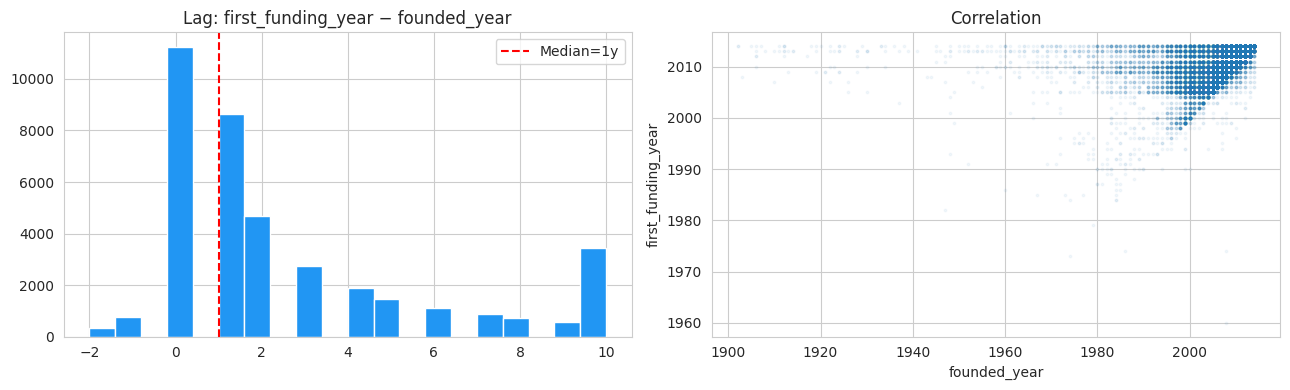

Correlation: 0.407 — strong, but funding year ≠ founding year → KNN safer.


In [ ]:
df_p = df[df['founded_year'].notna() & df['first_funding_at'].notna()].copy()
df_p['ff_year'] = pd.to_datetime(df_p['first_funding_at'], errors='coerce').dt.year
df_p['lag'] = df_p['ff_year'] - df_p['founded_year']

print("Lag (first_funding_year − founded_year):"); print(df_p['lag'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_p['lag'].clip(-2, 10).hist(bins=20, ax=axes[0], color='#2196F3')
axes[0].axvline(df_p['lag'].median(), color='red', linestyle='--',
                label=f'Median={df_p["lag"].median():.0f}y')
axes[0].set_title('Lag: first_funding_year − founded_year'); axes[0].legend()

axes[1].scatter(df_p['founded_year'], df_p['ff_year'], alpha=0.05, s=3)
axes[1].set_xlabel('founded_year'); axes[1].set_ylabel('first_funding_year')
axes[1].set_title('Correlation')
plt.tight_layout(); plt.show()

corr = df_p[['founded_year','ff_year']].corr().iloc[0,1]
print(f"Correlation: {corr:.3f} — strong, but funding year ≠ founding year → KNN safer.")

**→ Preprocessing Decision:**
1. Parse `founded_at` → fill `founded_year / month / quarter` where columns are null but string is available
2. Remaining nulls: **median imputation** — median of each column computed on the training set, applied to val/test
   - KNN was considered but rejected (memory error: ~1 GB pairwise distance matrix at this data scale)
3. `founded_at`, `first_funding_at`, `last_funding_at` are **dropped** after feature extraction (raw date strings not useful to the model)

### 3.3 `market` — 16.2% null

Null market: 8,824 (16.3%)

% null market by status:
           Has market  Null market
status                            
acquired         95.9          4.1
closed           97.0          3.0
operating        92.0          8.0


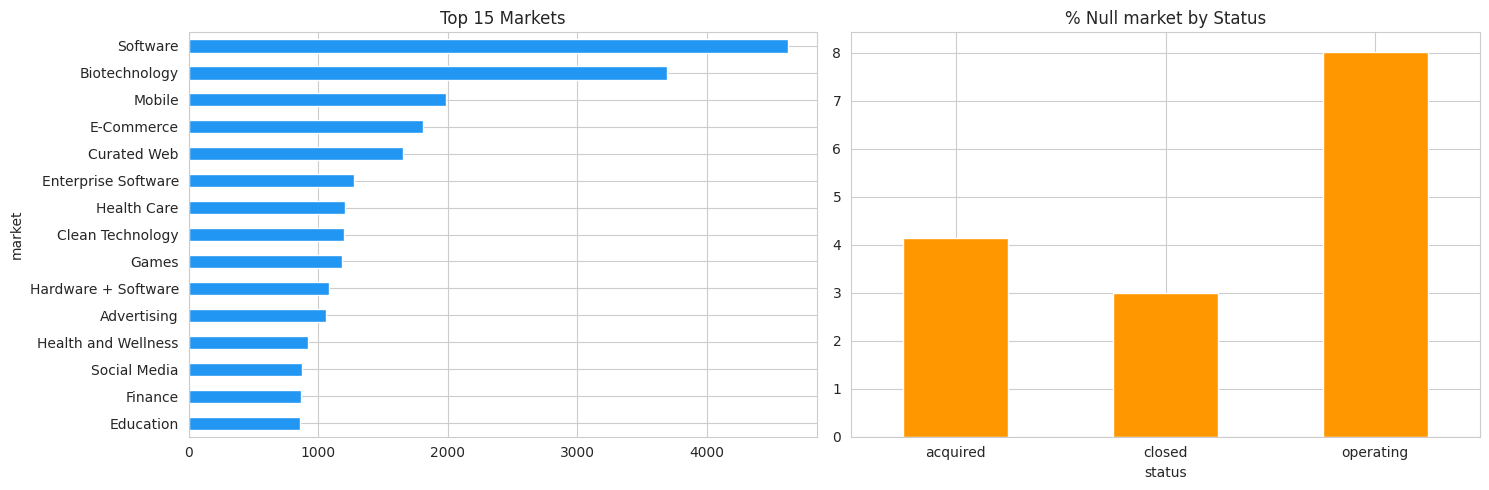

In [ ]:
print(f"Null market: {df['market'].isna().sum():,} ({df['market'].isna().mean()*100:.1f}%)")
df_s = df[df['status'].notna()].copy()
df_s['market_null'] = df_s['market'].isna()
ct = pd.crosstab(df_s['status'], df_s['market_null'], normalize='index') * 100
ct.columns = ['Has market','Null market']
print("\n% null market by status:"); print(ct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df['market'].value_counts().head(15).sort_values().plot(
    kind='barh', ax=axes[0], color='#2196F3', title='Top 15 Markets')
ct['Null market'].plot(kind='bar', ax=axes[1], color='#FF9800',
                       title='% Null market by Status')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

In [ ]:
# ── Market → Category mapping (Crunchbase taxonomy) ─────────────────────────
admin_services = str('Employer Benefits Programs, Human Resource Automation, Corporate IT, Distribution, Service Providers, Archiving Service, Call Center, Collection Agency, College Recruiting, Courier Service, Debt Collections, Delivery, Document Preparation, Employee Benefits, Extermination Service, Facilities Support Services, Housekeeping Service, Human Resources, Knowledge Management, Office Administration, Packaging Services, Physical Security, Project Management, Staffing Agency, Trade Shows, Virtual Workforce').split(', ')
advertising    = str('Creative Industries, Promotional, Advertising Ad Exchange, Ad Network, Ad Retargeting, Ad Server, Ad Targeting, Advertising, Advertising Platforms, Affiliate Marketing, Local Advertising, Mobile Advertising, Outdoor Advertising, SEM, Social Media Advertising, Video Advertising').split(', ')
agriculture    = str('Agriculture, AgTech, Animal Feed, Aquaculture, Equestrian, Farming, Forestry, Horticulture, Hydroponics, Livestock').split(', ')
app            = str('Application Performance Monitoring, App Stores, Application Platforms, Enterprise Application, App Discovery, Apps, Consumer Applications, Enterprise Applications, Mobile Apps, Reading Apps, Web Apps').split(', ')
artificial_intelli = str('Artificial Intelligence, Intelligent Systems, Machine Learning, Natural Language Processing, Predictive Analytics').split(', ')
biotechnology  = str('Synthetic Biology, Bio-Pharm, Bioinformatics, Biometrics, Biopharma, Biotechnology, Genetics, Life Science, Neuroscience, Quantified Self').split(', ')
clothing       = str('Fashion, Laundry and Dry-cleaning, Lingerie, Shoes').split(', ')
shopping       = str('Consumer Behavior, Customer Support Tools, Discounts, Reviews and Recommendations, Auctions, Classifieds, Collectibles, Consumer Reviews, Coupons, E-Commerce, E-Commerce Platforms, Flash Sale, Gift, Gift Card, Gift Exchange, Gift Registry, Group Buying, Local Shopping, Made to Order, Marketplace, Online Auctions, Personalization, Point of Sale, Price Comparison, Rental, Retail, Retail Technology, Shopping, Shopping Mall, Social Shopping, Sporting Goods, Vending and Concessions, Virtual Goods, Wholesale').split(', ')
community      = str("Self Development, Sex, Forums, Match-Making, Babies, Identity, Women, Kids, Entrepreneur, Networking, Adult, Baby, Cannabis, Children, Communities, Dating, Elderly, Family, Funerals, Humanitarian, Leisure, LGBT, Lifestyle, Men's, Online Forums, Parenting, Pet, Private Social Networking, Professional Networking, Q&A, Religion, Retirement, Sex Industry, Sex Tech, Social, Social Entrepreneurship, Teenagers, Virtual World, Wedding, Women's, Young Adults").split(', ')
electronics    = str('Mac, iPod Touch, Tablets, iPad, iPhone, Computer, Consumer Electronics, Drones, Electronics, Google Glass, Mobile Devices, Nintendo, Playstation, Roku, Smart Home, Wearables, Windows Phone, Xbox').split(', ')
consumer_goods = str('Commodities, Sunglasses, Groceries, Batteries, Cars, Beauty, Comics, Consumer Goods, Cosmetics, DIY, Drones, Eyewear, Fast-Moving Consumer Goods, Flowers, Furniture, Green Consumer Goods, Handmade, Jewelry, Lingerie, Shoes, Tobacco, Toys').split(', ')
content        = str('E-Books, MicroBlogging, Opinions, Blogging Platforms, Content Delivery Network, Content Discovery, Content Syndication, Creative Agency, DRM, EBooks, Journalism, News, Photo Editing, Photo Sharing, Photography, Printing, Publishing, Social Bookmarking, Video Editing, Video Streaming').split(', ')
data           = str('Optimization, A/B Testing, Analytics, Application Performance Management, Artificial Intelligence, Big Data, Bioinformatics, Biometrics, Business Intelligence, Consumer Research, Data Integration, Data Mining, Data Visualization, Database, Facial Recognition, Geospatial, Image Recognition, Intelligent Systems, Location Based Services, Machine Learning, Market Research, Natural Language Processing, Predictive Analytics, Product Research, Quantified Self, Speech Recognition, Test and Measurement, Text Analytics, Usability Testing').split(', ')
design         = str('Visualization, Graphics, Design, Designers, CAD, Consumer Research, Data Visualization, Fashion, Graphic Design, Human Computer Interaction, Industrial Design, Interior Design, Market Research, Mechanical Design, Product Design, Product Research, Usability Testing, UX Design, Web Design').split(', ')
education      = str('Universities, College Campuses, University Students, High Schools, All Students, Colleges, Alumni, Charter Schools, College Recruiting, Continuing Education, Corporate Training, E-Learning, EdTech, Education, Edutainment, Higher Education, Language Learning, MOOC, Music Education, Personal Development, Primary Education, Secondary Education, Skill Assessment, STEM Education, Textbook, Training, Tutoring, Vocational Education').split(', ')
energy         = str('Gas, Natural Gas Uses, Oil, Oil & Gas, Battery, Biofuel, Biomass Energy, Clean Energy, Electrical Distribution, Energy, Energy Efficiency, Energy Management, Energy Storage, Fossil Fuels, Fuel, Fuel Cell, Oil and Gas, Power Grid, Renewable Energy, Solar, Wind Energy').split(', ')
events         = str('Concerts, Event Management, Event Promotion, Events, Nightclubs, Nightlife, Reservations, Ticketing, Wedding').split(', ')
financial      = str('Debt Collecting, P2P Money Transfer, Investment Management, Trading, Accounting, Angel Investment, Asset Management, Auto Insurance, Banking, Bitcoin, Commercial Insurance, Commercial Lending, Consumer Lending, Credit, Credit Bureau, Credit Cards, Crowdfunding, Cryptocurrency, Debit Cards, Debt Collections, Finance, Financial Exchanges, Financial Services, FinTech, Fraud Detection, Funding Platform, Gift Card, Health Insurance, Hedge Funds, Impact Investing, Incubators, Insurance, InsurTech, Leasing, Lending, Life Insurance, Micro Lending, Mobile Payments, Payments, Personal Finance, Prediction Markets, Property Insurance, Real Estate Investment, Stock Exchanges, Trading Platform, Transaction Processing, Venture Capital, Virtual Currency, Wealth Management').split(', ')
food           = str('Specialty Foods, Bakery, Brewing, Cannabis, Catering, Coffee, Confectionery, Cooking, Craft Beer, Dietary Supplements, Distillery, Farmers Market, Food and Beverage, Food Delivery, Food Processing, Food Trucks, Fruit, Grocery, Nutrition, Organic Food, Recipes, Restaurants, Seafood, Snack Food, Tea, Tobacco, Wine And Spirits, Winery').split(', ')
gaming         = str('Game, Games, Casual Games, Console Games, Contests, Fantasy Sports, Gambling, Gamification, Gaming, MMO Games, Online Games, PC Games, Serious Games, Video Games').split(', ')
government     = str('Polling, Governance, CivicTech, Government, GovTech, Law Enforcement, Military, National Security, Politics, Public Safety, Social Assistance').split(', ')
hardware       = str('Cable, 3D, 3D Technology, Application Specific Integrated Circuit (ASIC), Augmented Reality, Cloud Infrastructure, Communication Hardware, Communications Infrastructure, Computer, Computer Vision, Consumer Electronics, Data Center, Data Center Automation, Data Storage, Drone Management, Drones, DSP, Electronic Design Automation (EDA), Electronics, Embedded Systems, Field-Programmable Gate Array (FPGA), Flash Storage, Google Glass, GPS, GPU, Hardware, Industrial Design, Laser, Lighting, Mechanical Design, Mobile Devices, Network Hardware, NFC, Nintendo, Optical Communication, Playstation, Private Cloud, Retail Technology, RFID, RISC, Robotics, Roku, Satellite Communication, Semiconductor, Sensor, Sex Tech, Telecommunications, Video Conferencing, Virtual Reality, Virtualization, Wearables, Windows Phone, Wireless, Xbox').split(', ')
health_care    = str('Senior Health, Physicians, Electronic Health Records, Doctors, Healthcare Services, Diagnostics, Alternative Medicine, Assisted Living, Assistive Technology, Biopharma, Cannabis, Child Care, Clinical Trials, Cosmetic Surgery, Dental, Diabetes, Dietary Supplements, Elder Care, Electronic Health Record (EHR), Emergency Medicine, Employee Benefits, Fertility, First Aid, Funerals, Genetics, Health Care, Health Diagnostics, Home Health Care, Hospital, Medical, Medical Device, mHealth, Nursing and Residential Care, Nutraceutical, Nutrition, Outpatient Care, Personal Health, Pharmaceutical, Psychology, Rehabilitation, Therapeutics, Veterinary, Wellness').split(', ')
it             = str('Distributors, Algorithms, ICT, M2M, Technology, Business Information Systems, CivicTech, Cloud Data Services, Cloud Management, Cloud Security, CMS, Contact Management, CRM, Cyber Security, Data Center, Data Center Automation, Data Integration, Data Mining, Data Visualization, Document Management, E-Signature, Email, GovTech, Identity Management, Information and Communications Technology (ICT), Information Services, Information Technology, Intrusion Detection, IT Infrastructure, IT Management, Management Information Systems, Messaging, Military, Network Security, Penetration Testing, Private Cloud, Reputation, Sales Automation, Scheduling, Social CRM, Spam Filtering, Technical Support, Unified Communications, Video Chat, Video Conferencing, Virtualization, VoIP').split(', ')
internet       = str('Online Identity, Cyber, Portals, Web Presence Management, Domains, Tracking, Web Tools, Curated Web, Search, Cloud Computing, Cloud Data Services, Cloud Infrastructure, Cloud Management, Cloud Storage, Darknet, Domain Registrar, E-Commerce Platforms, Ediscovery, Email, Internet, Internet of Things, ISP, Location Based Services, Messaging, Music Streaming, Online Forums, Online Portals, Private Cloud, Product Search, Search Engine, SEM, Semantic Search, Semantic Web, SEO, SMS, Social Media, Social Media Management, Social Network, Unified Communications, Vertical Search, Video Chat, Video Conferencing, Visual Search, VoIP, Web Browsers, Web Hosting').split(', ')
invest         = str('Angel Investment, Banking, Commercial Lending, Consumer Lending, Credit, Credit Cards, Financial Exchanges, Funding Platform, Hedge Funds, Impact Investing, Incubators, Micro Lending, Stock Exchanges, Trading Platform, Venture Capital').split(', ')
manufacturing  = str('Innovation Engineering, Civil Engineers, Heavy Industry, Engineering Firms, Systems, 3D Printing, Advanced Materials, Foundries, Industrial, Industrial Automation, Industrial Engineering, Industrial Manufacturing, Machinery Manufacturing, Manufacturing, Paper Manufacturing, Plastics and Rubber Manufacturing, Textiles, Wood Processing').split(', ')
media          = str('Writers, Creative, Television, Entertainment, Media, Advice, Animation, Art, Audio, Audiobooks, Blogging Platforms, Broadcasting, Celebrity, Concerts, Content, Content Creators, Content Discovery, Content Syndication, Creative Agency, Digital Entertainment, Digital Media, DRM, EBooks, Edutainment, Event Management, Event Promotion, Events, Film, Film Distribution, Film Production, Guides, In-Flight Entertainment, Independent Music, Internet Radio, Journalism, Media and Entertainment, Motion Capture, Music, Music Education, Music Label, Music Streaming, Music Venues, Musical Instruments, News, Nightclubs, Nightlife, Performing Arts, Photo Editing, Photo Sharing, Photography, Podcast, Printing, Publishing, Reservations, Social Media, Social News, Theatre, Ticketing, TV, TV Production, Video, Video Editing, Video on Demand, Video Streaming, Virtual World').split(', ')
message        = str('Unifed Communications, Chat, Email, Meeting Software, Messaging, SMS, Unified Communications, Video Chat, Video Conferencing, VoIP, Wired Telecommunications').split(', ')
mobile         = str('Android, Google Glass, iOS, mHealth, Mobile, Mobile Apps, Mobile Devices, Mobile Payments, Windows Phone, Wireless').split(', ')
music          = str('Audio, Audiobooks, Independent Music, Internet Radio, Music, Music Education, Music Label, Music Streaming, Musical Instruments, Podcast').split(', ')
resource       = str('Biofuel, Biomass Energy, Fossil Fuels, Mineral, Mining, Mining Technology, Natural Resources, Oil and Gas, Precious Metals, Solar, Timber, Water, Wind Energy').split(', ')
navigation     = str('Maps, Geospatial, GPS, Indoor Positioning, Location Based Services, Mapping Services, Navigation').split(', ')
other          = str('Mass Customization, Monetization, Testing, Subscription Businesses, Mobility, Incentives, Peer-to-Peer, Nonprofits, Alumni, Association, B2B, B2C, Blockchain, Charity, Collaboration, Collaborative Consumption, Commercial, Consumer, Crowdsourcing, Customer Service, Desktop Apps, Emerging Markets, Enterprise, Ethereum, Franchise, Freemium, Generation Y, Generation Z, Homeless Shelter, Infrastructure, Knowledge Management, LGBT Millennials, Non Profit, Peer to Peer, Professional Services, Project Management, Real Time, Retirement, Service Industry, Sharing Economy, Small and Medium Businesses, Social Bookmarking, Social Impact, Subscription Service, Technical Support, Underserved Children, Universities').split(', ')
payment        = str('Billing, Bitcoin, Credit Cards, Cryptocurrency, Debit Cards, Fraud Detection, Mobile Payments, Payments, Transaction Processing, Virtual Currency').split(', ')
platforms      = str('Development Platforms, Android, Facebook, Google, Google Glass, iOS, Linux, macOS, Nintendo, Operating Systems, Playstation, Roku, Tizen, Twitter, WebOS, Windows, Windows Phone, Xbox').split(', ')
privacy        = str('Digital Rights Management, Personal Data, Cloud Security, Corrections Facilities, Cyber Security, DRM, E-Signature, Fraud Detection, Homeland Security, Identity Management, Intrusion Detection, Law Enforcement, Network Security, Penetration Testing, Physical Security, Privacy, Security').split(', ')
services       = str('Funeral Industry, English-Speaking, Spas, Plumbers, Service Industries, Staffing Firms, Translation, Career Management, Business Services, Services, Accounting, Business Development, Career Planning, Compliance, Consulting, Customer Service, Employment, Environmental Consulting, Field Support, Freelance, Intellectual Property, Innovation Management, Legal, Legal Tech, Management Consulting, Outsourcing, Professional Networking, Quality Assurance, Recruiting, Risk Management, Social Recruiting, Translation Service').split(', ')
realestate     = str('Office Space, Self Storage, Brokers, Storage, Home Owners, Self Storage , Realtors, Home & Garden, Utilities, Home Automation, Architecture, Building Maintenance, Building Material, Commercial Real Estate, Construction, Coworking, Facility Management, Fast-Moving Consumer Goods, Green Building, Home and Garden, Home Decor, Home Improvement, Home Renovation, Home Services, Interior Design, Janitorial Service, Landscaping, Property Development, Property Management, Real Estate, Real Estate Investment, Rental Property, Residential, Self-Storage, Smart Building, Smart Cities, Smart Home, Timeshare, Vacation Rental').split(', ')
sales          = str('Advertising, Affiliate Marketing, App Discovery, App Marketing, Brand Marketing, Cause Marketing, Content Marketing, CRM, Digital Marketing, Digital Signage, Direct Marketing, Direct Sales, Email Marketing, Lead Generation, Lead Management, Local, Local Advertising, Local Business, Loyalty Programs, Marketing, Marketing Automation, Mobile Advertising, Multi-level Marketing, Outdoor Advertising, Personal Branding, Public Relations, Sales, Sales Automation, SEM, SEO, Social CRM, Social Media Advertising, Social Media Management, Social Media Marketing, Sponsorship, Video Advertising').split(', ')
science        = str('Face Recognition, New Technologies, Advanced Materials, Aerospace, Artificial Intelligence, Bioinformatics, Biometrics, Biopharma, Biotechnology, Chemical, Chemical Engineering, Civil Engineering, Embedded Systems, Environmental Engineering, Human Computer Interaction, Industrial Automation, Industrial Engineering, Intelligent Systems, Laser, Life Science, Marine Technology, Mechanical Engineering, Nanotechnology, Neuroscience, Nuclear, Quantum Computing, Robotics, Semiconductor, Software Engineering, STEM Education').split(', ')
software       = str('Business Productivity, 3D Technology, Android, App Discovery, Application Performance Management, Apps, Artificial Intelligence, Augmented Reality, Billing, Bitcoin, Browser Extensions, CAD, Cloud Computing, Cloud Management, CMS, Computer Vision, Consumer Applications, Consumer Software, Contact Management, CRM, Cryptocurrency, Data Center Automation, Data Integration, Data Storage, Data Visualization, Database, Developer APIs, Developer Platform, Developer Tools, Document Management, Drone Management, E-Learning, EdTech, Electronic Design Automation (EDA), Embedded Software, Embedded Systems, Enterprise Applications, Enterprise Resource Planning (ERP), Enterprise Software, Facial Recognition, File Sharing, IaaS, Image Recognition, iOS, Linux, Machine Learning, macOS, Marketing Automation, Meeting Software, Mobile Apps, Mobile Payments, MOOC, Natural Language Processing, Open Source, Operating Systems, PaaS, Predictive Analytics, Presentation Software, Presentations, Private Cloud, Productivity Tools, QR Codes, Reading Apps, Retail Technology, Robotics, SaaS, Sales Automation, Scheduling, Sex Tech, Simulation, SNS, Social CRM, Software, Software Engineering, Speech Recognition, Task Management, Text Analytics, Transaction Processing, Video Conferencing, Virtual Assistant, Virtual Currency, Virtual Desktop, Virtual Goods, Virtual Reality, Virtual World, Virtualization, Web Apps, Web Browsers, Web Development').split(', ')
sports         = str('American Football, Baseball, Basketball, Boating, Cricket, Cycling, Diving, eSports, Fantasy Sports, Fitness, Golf, Hockey, Hunting, Outdoors, Racing, Recreation, Rugby, Sailing, Skiing, Soccer, Sporting Goods, Sports, Surfing, Swimming, Table Tennis, Tennis, Ultimate Frisbee, Volley Ball').split(', ')
sustainability = str('Green, Wind, Biomass Power Generation, Renewable Tech, Environmental Innovation, Renewable Energies, Clean Technology, Biofuel, Biomass Energy, Clean Energy, CleanTech, Energy Efficiency, Environmental Engineering, Green Building, Green Consumer Goods, GreenTech, Natural Resources, Organic, Pollution Control, Recycling, Renewable Energy, Solar, Sustainability, Waste Management, Water Purification, Wind Energy').split(', ')
transportation = str('Taxis, Air Transportation, Automotive, Autonomous Vehicles, Car Sharing, Courier Service, Delivery Service, Electric Vehicle, Ferry Service, Fleet Management, Food Delivery, Freight Service, Last Mile Transportation, Limousine Service, Logistics, Marine Transportation, Parking, Ports and Harbors, Procurement, Public Transportation, Railroad, Recreational Vehicles, Ride Sharing, Same Day Delivery, Shipping, Shipping Broker, Space Travel, Supply Chain Management, Taxi Service, Transportation, Warehousing, Water Transportation').split(', ')
travel         = str('Adventure Travel, Amusement Park and Arcade, Business Travel, Casino, Hospitality, Hotel, Museums and Historical Sites, Parks, Resorts, Timeshare, Tour Operator, Tourism, Travel, Travel Accommodations, Travel Agency, Vacation Rental').split(', ')
video          = str('Animation, Broadcasting, Film, Film Distribution, Film Production, Motion Capture, TV, TV Production, Video, Video Editing, Video on Demand, Video Streaming').split(', ')

# Build lookup: market_value → category_name (first match wins)
_MARKET_CATEGORY_MAP = {}
_category_lists = {
    'admin_services': admin_services, 'advertising': advertising, 'agriculture': agriculture,
    'app': app, 'artificial_intelligence': artificial_intelli, 'biotechnology': biotechnology,
    'clothing': clothing, 'shopping': shopping, 'community': community, 'electronics': electronics,
    'consumer_goods': consumer_goods, 'content': content, 'data': data, 'design': design,
    'education': education, 'energy': energy, 'events': events, 'financial': financial,
    'food': food, 'gaming': gaming, 'government': government, 'hardware': hardware,
    'health_care': health_care, 'it': it, 'internet': internet, 'invest': invest,
    'manufacturing': manufacturing, 'media': media, 'messaging': message, 'mobile': mobile,
    'music': music, 'natural_resources': resource, 'navigation': navigation, 'other': other,
    'payment': payment, 'platforms': platforms, 'privacy': privacy, 'services': services,
    'real_estate': realestate, 'sales_marketing': sales, 'science': science, 'software': software,
    'sports': sports, 'sustainability': sustainability, 'transportation': transportation,
    'travel': travel, 'video': video,
}
for _cat, _markets in _category_lists.items():
    for _m in _markets:
        _m_stripped = _m.strip()
        if _m_stripped and _m_stripped not in _MARKET_CATEGORY_MAP:
            _MARKET_CATEGORY_MAP[_m_stripped] = _cat

def map_market_to_category(market_value):
    """Map a raw market string to its industry category. Returns 'Unknown' for nulls/unmapped."""
    if pd.isna(market_value):
        return 'Unknown'
    return _MARKET_CATEGORY_MAP.get(str(market_value).strip(), 'other')

df['market_category'] = df['market'].map(map_market_to_category)

print(f"market_category value counts (top 20):")
print(df['market_category'].value_counts().head(20))
print(f"\nTotal unique categories: {df['market_category'].nunique()}")
print(f"Rows mapped to \'other\' or \'Unknown\': {(df['market_category'].isin(['other','Unknown'])).sum():,}")


In [ ]:
# ── market_category distribution and status breakdown ────────────────────────
df_s = df[df['status'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Distribution
cat_counts = df['market_category'].value_counts()
cat_counts.plot(kind='barh', ax=axes[0], color='#2196F3')
axes[0].set_title('Market Category Distribution')
axes[0].set_xlabel('Count')

# Acquisition rate by category
df_s['acquired'] = (df_s['status'] == 'acquired').astype(int)
cat_acq = df_s.groupby('market_category')['acquired'].mean().sort_values(ascending=False)
cat_acq.plot(kind='barh', ax=axes[1], color='#4CAF50')
global_acq = df_s['acquired'].mean()
axes[1].axvline(global_acq, color='red', linestyle='--', label=f'Global mean ({global_acq:.2%})')
axes[1].set_title('Acquisition Rate by Market Category')
axes[1].set_xlabel('Acquisition Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nStatus breakdown by market_category (%):")
ct = pd.crosstab(df_s['market_category'], df_s['status'], normalize='index') * 100
print(ct.round(1).sort_values('acquired', ascending=False).to_string())


**→ Preprocessing Decision:**
Fill null `market` with `"Unknown"`.
`"Unknown"` receives its own target-encoded value — the model can learn from this missingness pattern.

Additionally, map `market` → `market_category` using the Crunchbase industry grouping (47 categories).
`market_category` is used for target encoding in place of raw `market` to reduce cardinality from ~700 unique values to ~47 interpretable industry buckets.

### 3.4 `country_code` (18.6% null) and `state_code` (44.4% null)

In [ ]:
n_cc  = df['country_code'].isna().sum()
n_sc  = df['state_code'].isna().sum()
n_sc_fills_cc = (df['state_code'].notna() & df['country_code'].isna()).sum()
print(f"country_code null: {n_cc:,} ({n_cc/len(df)*100:.1f}%)")
print(f"state_code   null: {n_sc:,} ({n_sc/len(df)*100:.1f}%)")
print(f"state not-null but country null: {n_sc_fills_cc:,}  ← recoverable")
print("\nCountries with state_code filled:")
print(df[df['state_code'].notna()]['country_code'].value_counts().head(5))

country_code null: 10,129 (18.7%)
state_code   null: 24,133 (44.4%)
state not-null but country null: 0  ← recoverable

Countries with state_code filled:
country_code
USA    28767
CAN     1394
Name: count, dtype: int64


geo_cluster distribution (top 10):
geo_cluster
USA-Other            17909
Unknown              10129
USA-SiliconValley     5620
GBR                   2642
USA-NY                2493
CAN                   1405
CHN                   1239
USA-Boston            1081
DEU                    968
USA-LA                 903
Name: count, dtype: int64


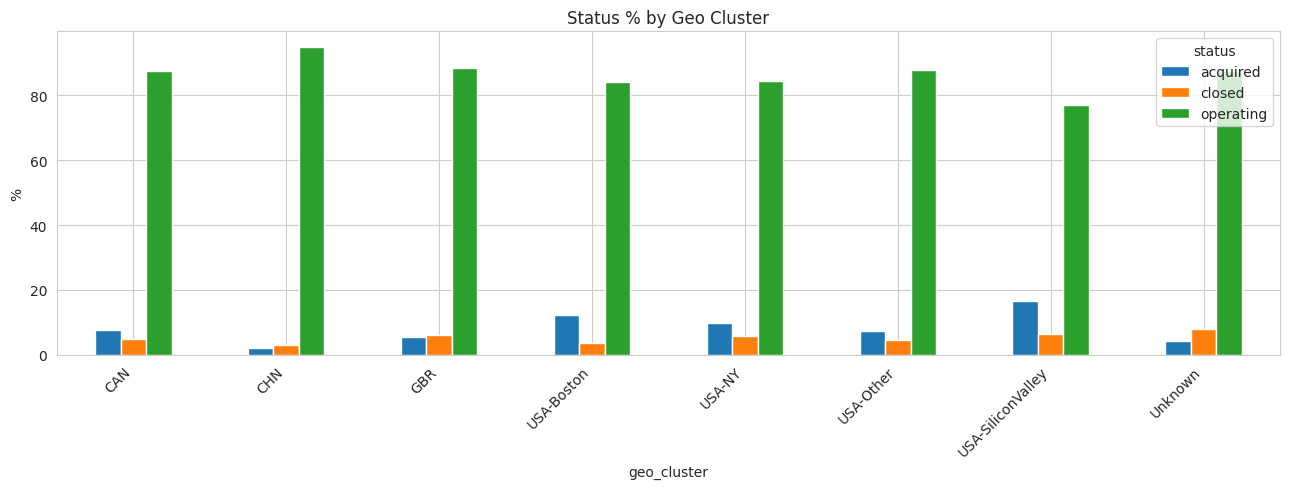

In [ ]:
SV_CITIES = {'San Francisco','San Jose','Palo Alto','Mountain View','Menlo Park',
             'Redwood City','Sunnyvale','Santa Clara','Cupertino','San Mateo','Burlingame'}
NY_CITIES  = {'New York','Brooklyn','Manhattan','New York City'}
BOS_CITIES = {'Boston','Cambridge','Somerville','Waltham'}
SEA_CITIES = {'Seattle','Bellevue','Redmond','Kirkland'}
LA_CITIES  = {'Los Angeles','Santa Monica','Venice','Culver City','Pasadena'}

def geo_cluster(row):
    cc   = row.get('country_code')
    city = str(row.get('city', ''))
    if pd.isna(cc):
        return 'Unknown'
    if cc != 'USA':
        return cc
    if city in SV_CITIES:  return 'USA-SiliconValley'
    if city in NY_CITIES:  return 'USA-NY'
    if city in BOS_CITIES: return 'USA-Boston'
    if city in SEA_CITIES: return 'USA-Seattle'
    if city in LA_CITIES:  return 'USA-LA'
    return 'USA-Other'

df_geo = df.copy()
df_geo['geo_cluster'] = df_geo.apply(geo_cluster, axis=1)
print("geo_cluster distribution (top 10):")
print(df_geo['geo_cluster'].value_counts().head(10))

top_cl = df_geo['geo_cluster'].value_counts().head(8).index
df_plot = df_geo[df_geo['geo_cluster'].isin(top_cl) & df_geo['status'].notna()]
ct2 = pd.crosstab(df_plot['geo_cluster'], df_plot['status'], normalize='index') * 100
ct2.plot(kind='bar', figsize=(13, 5), title='Status % by Geo Cluster')
plt.ylabel('%'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

**→ Preprocessing Decision:**
1. Fill `country_code` nulls with `"Unknown"` (analysis showed 0 rows where state_code could recover country_code)
2. Create `geo_cluster`: Silicon Valley / NY / Boston / Seattle / LA / USA-Other / country_code / Unknown
3. Drop `state_code`, `region`, `city` (redundant after clustering)

## 4. Outliers and Skewed Distributions

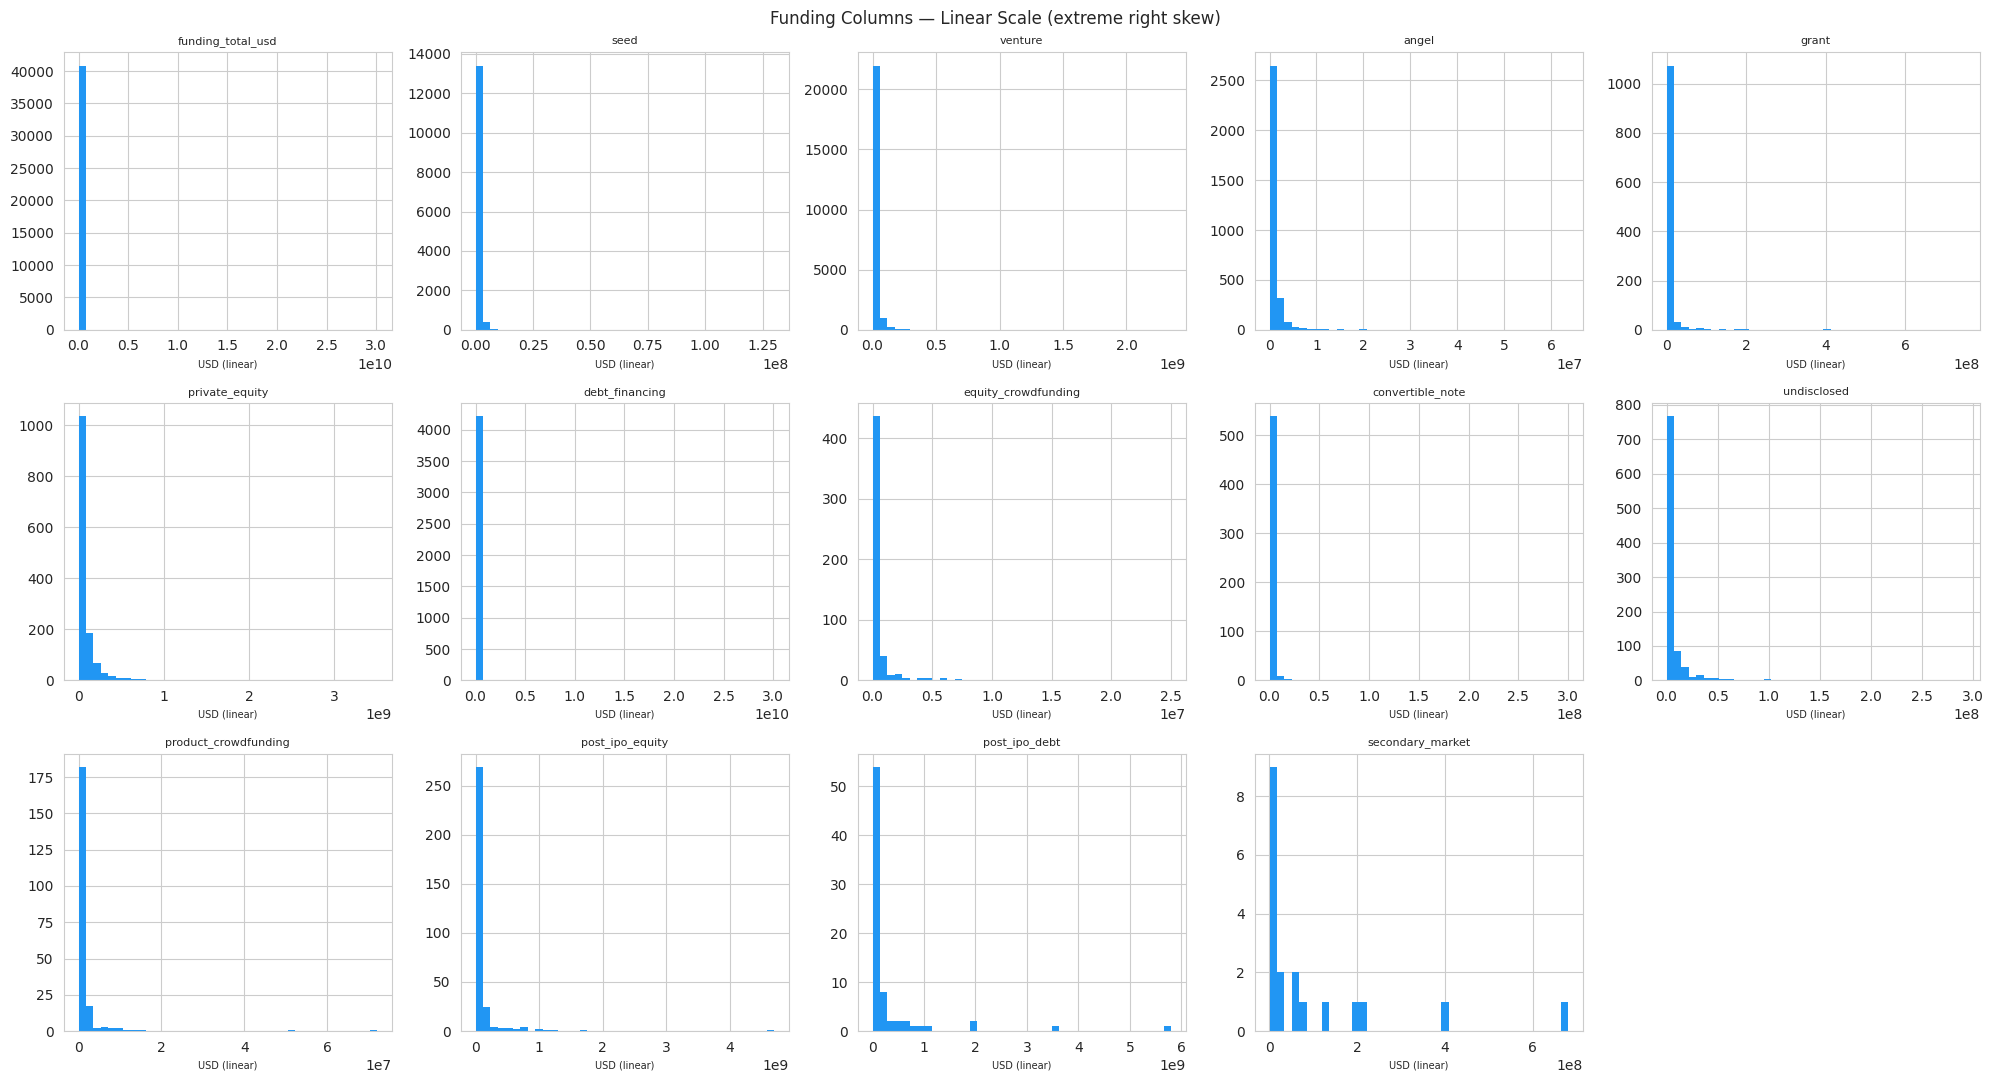

In [ ]:
FUNDING_AMOUNT_COLS = [
    'funding_total_usd','seed','venture','angel','grant','private_equity',
    'debt_financing','equity_crowdfunding','convertible_note','undisclosed',
    'product_crowdfunding','post_ipo_equity','post_ipo_debt','secondary_market'
]
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
axes = axes.flatten()
for i, col in enumerate(FUNDING_AMOUNT_COLS):
    data = df[col].dropna(); data = data[data > 0]
    if len(data): axes[i].hist(data, bins=40, color='#2196F3', edgecolor='none')
    axes[i].set_title(col, fontsize=8); axes[i].set_xlabel('USD (linear)', fontsize=7)
for j in range(len(FUNDING_AMOUNT_COLS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Funding Columns — Linear Scale (extreme right skew)', fontsize=12)
plt.tight_layout(); plt.show()

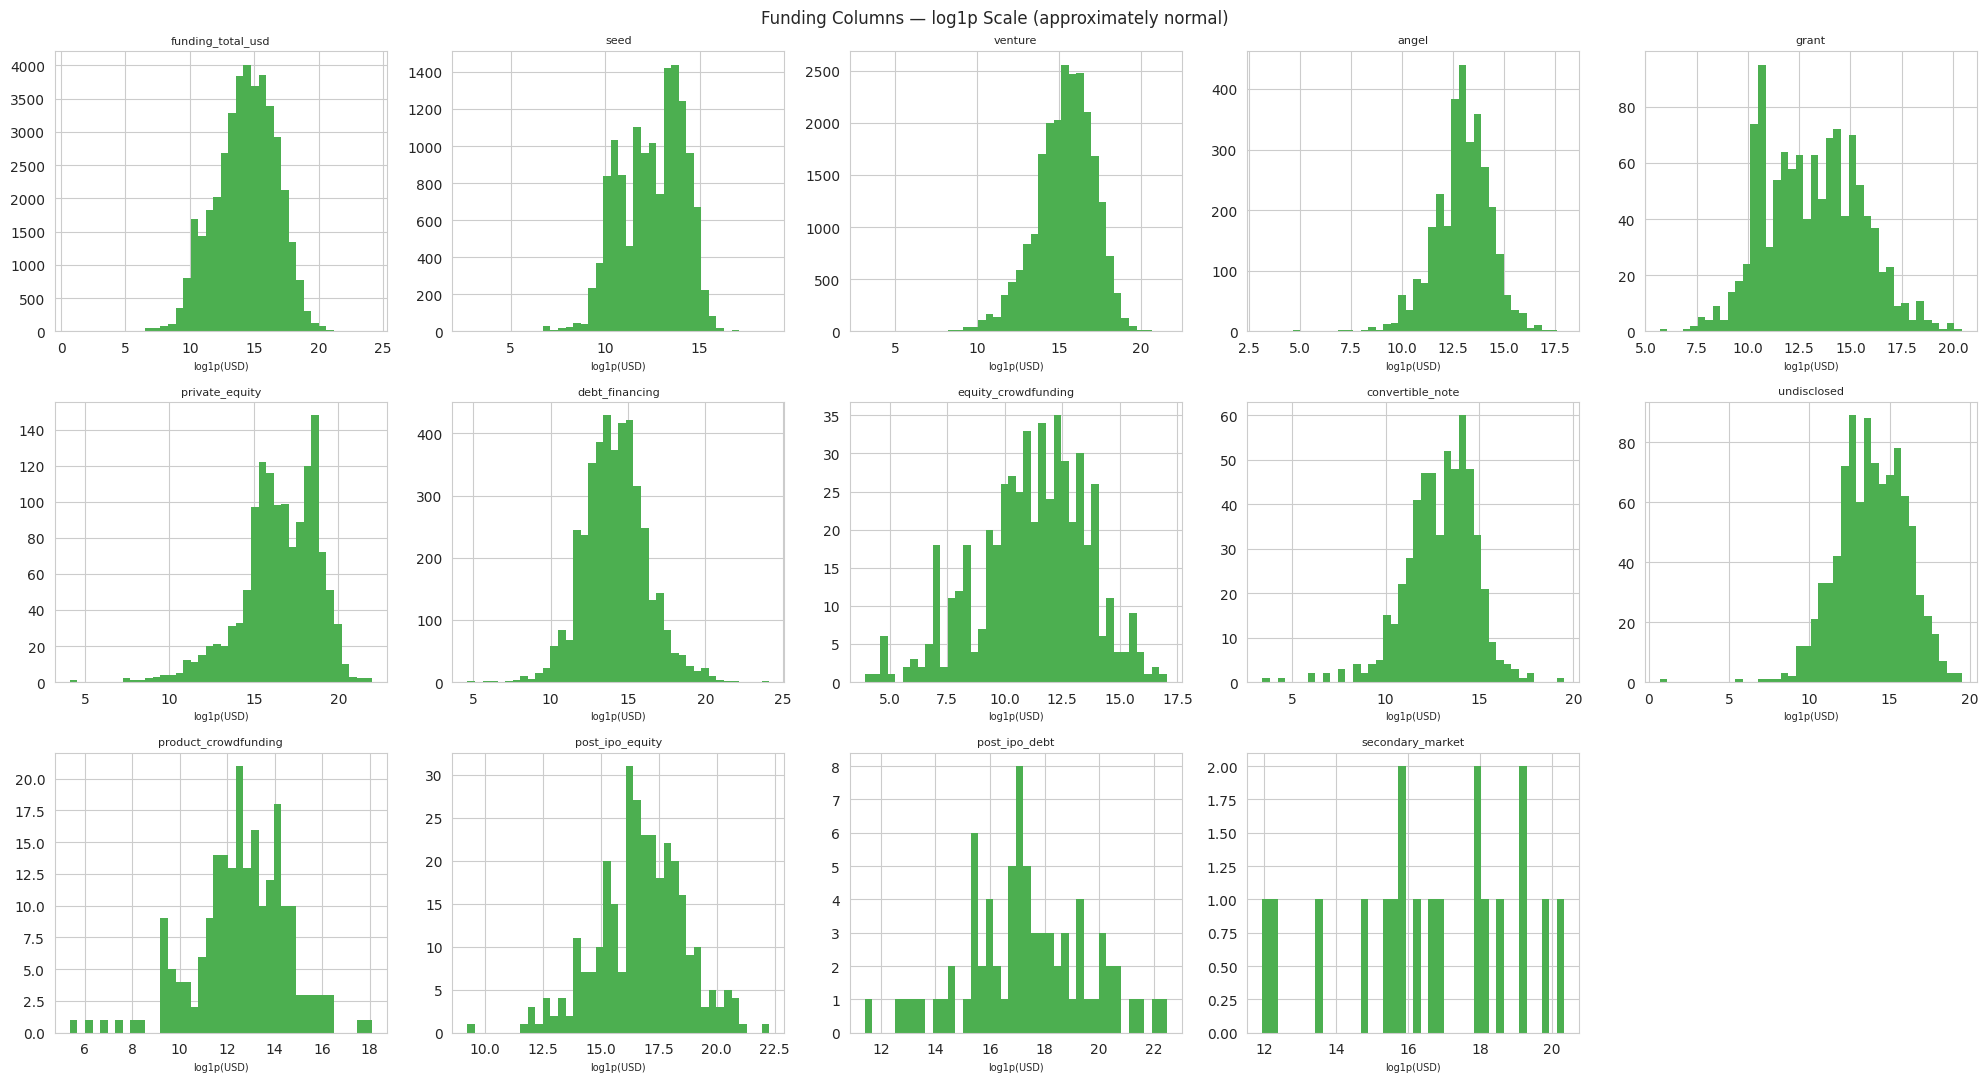

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
axes = axes.flatten()
for i, col in enumerate(FUNDING_AMOUNT_COLS):
    data = df[col].dropna(); data = data[data > 0]
    if len(data): axes[i].hist(np.log1p(data), bins=40, color='#4CAF50', edgecolor='none')
    axes[i].set_title(col, fontsize=8); axes[i].set_xlabel('log1p(USD)', fontsize=7)
for j in range(len(FUNDING_AMOUNT_COLS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Funding Columns — log1p Scale (approximately normal)', fontsize=12)
plt.tight_layout(); plt.show()

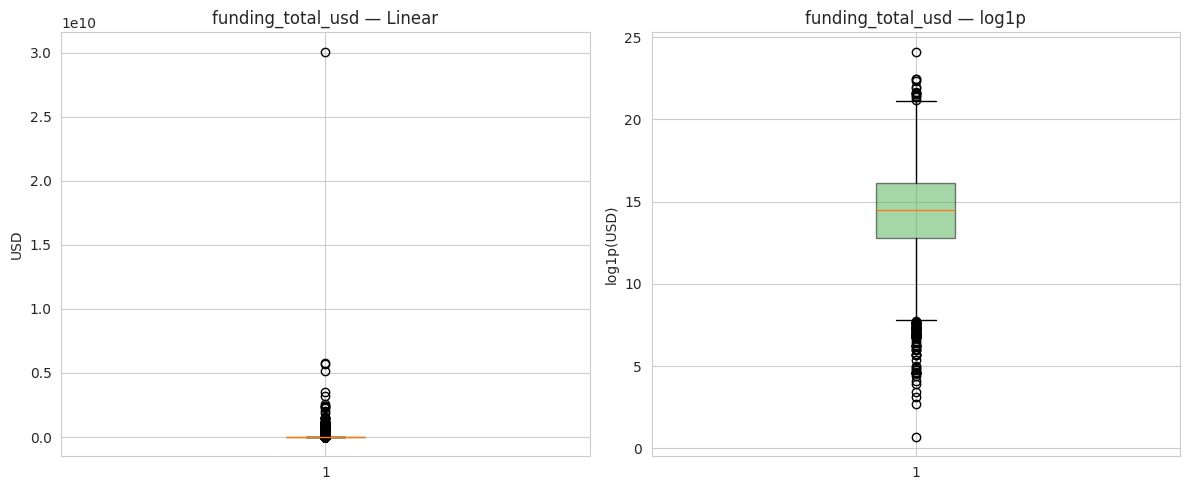

In [ ]:
data = df['funding_total_usd'].dropna(); data = data[data > 0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(data, patch_artist=True, boxprops=dict(facecolor='#2196F3', alpha=0.5))
axes[0].set_title('funding_total_usd — Linear'); axes[0].set_ylabel('USD')
axes[1].boxplot(np.log1p(data), patch_artist=True, boxprops=dict(facecolor='#4CAF50', alpha=0.5))
axes[1].set_title('funding_total_usd — log1p'); axes[1].set_ylabel('log1p(USD)')
plt.tight_layout(); plt.show()

**→ Preprocessing Decision:**
Apply `log1p` to all funding amount columns. New columns named with `log_` prefix (e.g., `log_funding_total_usd`).
- `log1p(x) = log(x+1)` handles zeros safely
- Original columns are **kept** (needed for round binarization step that follows)

## 5. Funding Rounds Analysis

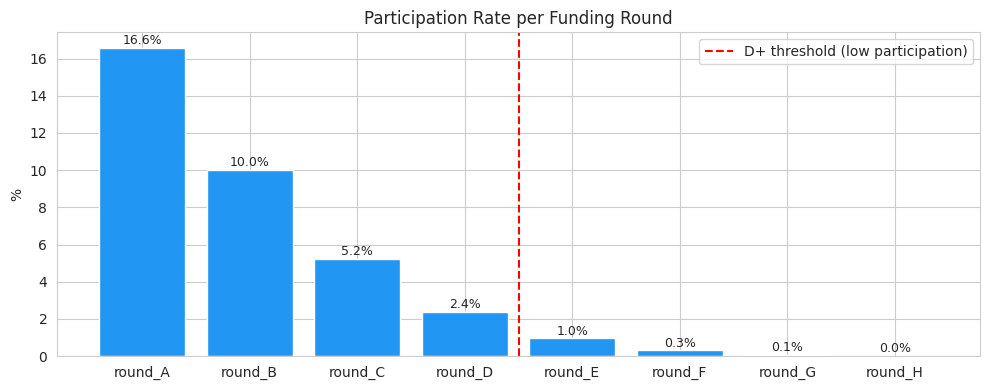

round_A    16.58
round_B    10.03
round_C     5.23
round_D     2.37
round_E     0.95
round_F     0.32
round_G     0.06
round_H     0.01
dtype: float64


In [ ]:
ROUND_COLS = ['round_A','round_B','round_C','round_D','round_E','round_F','round_G','round_H']
participation = {c: (df[c] > 0).mean()*100 for c in ROUND_COLS}
p_series = pd.Series(participation)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(p_series.index, p_series.values, color='#2196F3')
for bar, v in zip(bars, p_series.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{v:.1f}%', ha='center', fontsize=9)
ax.axvline(3.5, color='red', linestyle='--', label='D+ threshold (low participation)')
ax.set_title('Participation Rate per Funding Round'); ax.set_ylabel('%'); ax.legend()
plt.tight_layout(); plt.show()
print(p_series.round(2))

Status distribution by late-stage round (D+):
status          acquired  closed  operating
has_late_round                             
False                7.2     5.5       87.3
True                21.8     3.3       74.9


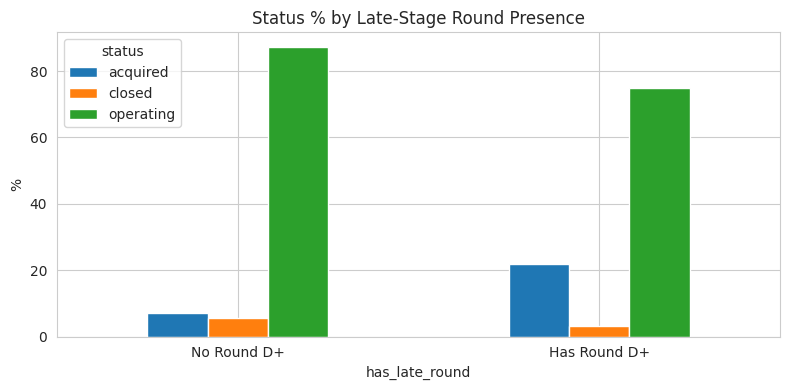

In [ ]:
df_r = df[df['status'].notna()].copy()
df_r['has_late_round'] = df_r[['round_D','round_E','round_F','round_G','round_H']].fillna(0).max(axis=1) > 0
ct = pd.crosstab(df_r['has_late_round'], df_r['status'], normalize='index') * 100
print("Status distribution by late-stage round (D+):"); print(ct.round(1))
ct.plot(kind='bar', figsize=(8, 4), title='Status % by Late-Stage Round Presence')
plt.ylabel('%'); plt.xticks([0,1], ['No Round D+','Has Round D+'], rotation=0)
plt.tight_layout(); plt.show()

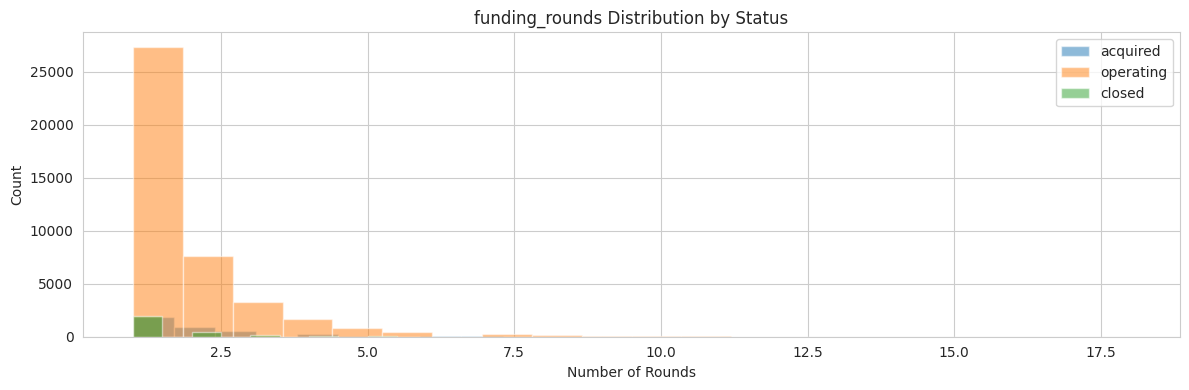

             count  mean   std  min  25%  50%  75%   max
status                                                  
acquired    3692.0  2.01  1.40  1.0  1.0  2.0  3.0  15.0
closed      2603.0  1.43  0.97  1.0  1.0  1.0  2.0  11.0
operating  41829.0  1.69  1.30  1.0  1.0  1.0  2.0  18.0


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for status in df_r['status'].unique():
    df_r[df_r['status']==status]['funding_rounds'].dropna().hist(
        bins=20, alpha=0.5, label=status, ax=ax)
ax.set_title('funding_rounds Distribution by Status')
ax.set_xlabel('Number of Rounds'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()
print(df_r.groupby('status')['funding_rounds'].describe().round(2))

**→ Preprocessing Decision:**
1. Add `has_round_A`, `has_round_B`, `has_round_C` binary flags (1 if amount > 0) alongside original columns
2. Create `round_D_plus` = **sum** of round_D through round_H (total late-stage funding amount)
3. Drop `round_D`, `round_E`, `round_F`, `round_G`, `round_H` — summarised by `round_D_plus`
4. Done **after** the log transform step so log captures original amounts first

## 6. Funding Timeline Features

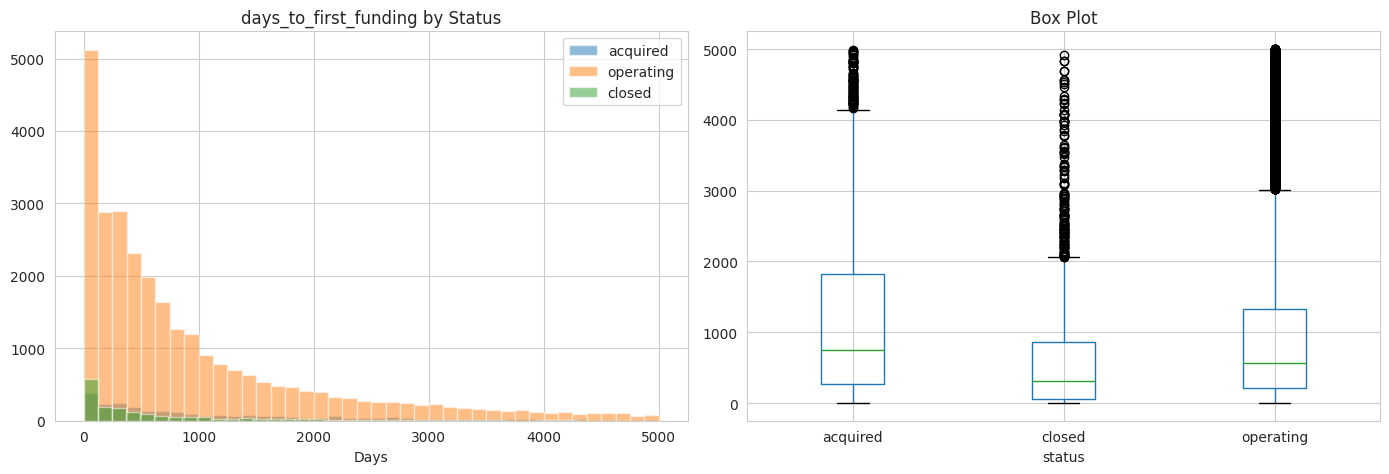

Median days_to_first_funding by status:
status
acquired     733.0
closed       238.0
operating    550.0
Name: days_to_first_funding, dtype: float64


In [ ]:
df_t = df[df['status'].notna()].copy()
df_t['founded_dt']      = pd.to_datetime(df_t['founded_at'], errors='coerce')
df_t['first_funding_dt'] = pd.to_datetime(df_t['first_funding_at'], errors='coerce')
df_t['last_funding_dt']  = pd.to_datetime(df_t['last_funding_at'], errors='coerce')
df_t['days_to_first_funding'] = (df_t['first_funding_dt'] - df_t['founded_dt']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for st in ['acquired','operating','closed']:
    s = df_t[df_t['status']==st]['days_to_first_funding']
    s[s.between(0,5000)].hist(bins=40, alpha=0.5, label=st, ax=axes[0])
axes[0].set_title('days_to_first_funding by Status'); axes[0].set_xlabel('Days'); axes[0].legend()
df_t[df_t['days_to_first_funding'].between(0,5000)].boxplot(
    column='days_to_first_funding', by='status', ax=axes[1])
axes[1].set_title('Box Plot'); plt.suptitle(''); plt.tight_layout(); plt.show()
print("Median days_to_first_funding by status:")
print(df_t.groupby('status')['days_to_first_funding'].median().round(0))

**→ Preprocessing Decision:**
Add `days_to_first_funding` = `first_funding_at` − `founded_at` (days).
Null values (missing dates) are imputed with **median fit on training set**.
`founded_at`, `first_funding_at`, `last_funding_at` are dropped after this step — raw date strings not needed by the model.

## 7. Target Encoding for Categorical Features

In [ ]:
print(f"Unique market_categories: {df['market_category'].nunique()}")
print(f"Unique markets (raw):     {df['market'].nunique()}")
print(f"Unique country_codes:     {df['country_code'].nunique()}")
print("\nUsing market_category instead of raw market reduces cardinality from ~700 to ~47.")
print("Target encoding collapses each category to 2 informative numeric values.")


Unique markets:        753
Unique country_codes:  115

One-hot encoding market would add hundreds of columns — impractical.
Target encoding collapses each category to 2 informative numeric values.


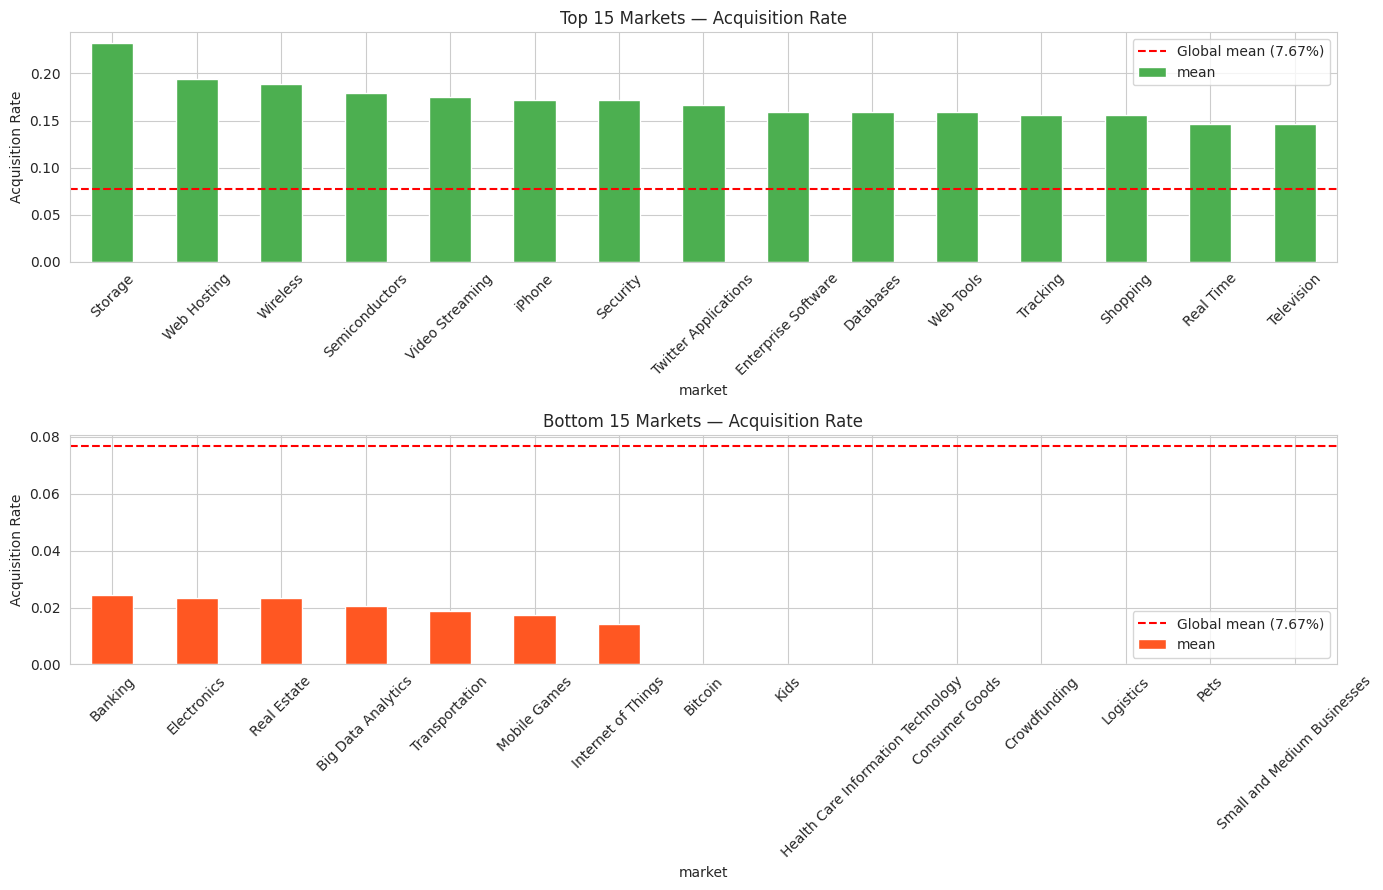

In [ ]:
df_e = df[df['status'].notna()].copy()
df_e['acquired'] = (df_e['status']=='acquired').astype(int)
mkt = df_e.groupby('market_category')['acquired'].agg(['mean','count'])
mkt = mkt[mkt['count']>=30].sort_values('mean', ascending=False)
global_acq = df_e['acquired'].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
mkt.head(15)['mean'].plot(kind='bar', ax=axes[0], color='#4CAF50',
                          title='Top 15 Market Categories — Acquisition Rate')
axes[0].axhline(global_acq, color='red', linestyle='--', label=f'Global mean ({global_acq:.2%})')
axes[0].set_ylabel('Acquisition Rate'); axes[0].legend(); axes[0].tick_params(axis='x', rotation=45)

mkt.tail(15)['mean'].plot(kind='bar', ax=axes[1], color='#FF5722',
                           title='Bottom 15 Market Categories — Acquisition Rate')
axes[1].axhline(global_acq, color='red', linestyle='--', label=f'Global mean ({global_acq:.2%})')
axes[1].set_ylabel('Acquisition Rate'); axes[1].legend(); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


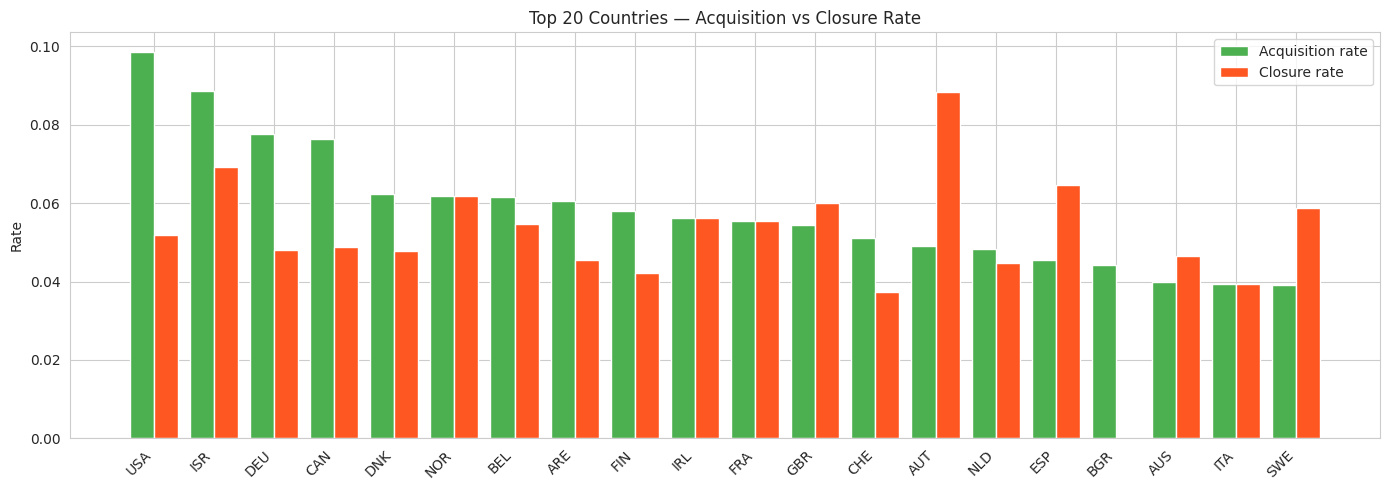

              acq_rate  cls_rate  count
country_code                           
USA              0.099     0.052  28233
ISR              0.088     0.069    678
DEU              0.078     0.048    939
CAN              0.076     0.049   1351
DNK              0.062     0.048    209
NOR              0.062     0.062     97
BEL              0.062     0.055    146
ARE              0.061     0.045     66
FIN              0.058     0.042    190
IRL              0.056     0.056    303
FRA              0.055     0.055    847
GBR              0.054     0.060   2595
CHE              0.051     0.037    215
AUT              0.049     0.088    102
NLD              0.048     0.045    290
ESP              0.046     0.065    527
BGR              0.044     0.000     68
AUS              0.040     0.047    301
ITA              0.039     0.039    305
SWE              0.039     0.059    307


In [ ]:
df_e['closed'] = (df_e['status']=='closed').astype(int)
cc = df_e.groupby('country_code').agg(
    acq_rate=('acquired','mean'), cls_rate=('closed','mean'), count=('acquired','count'))
cc = cc[cc['count']>=50].sort_values('acq_rate', ascending=False).head(20)

x = np.arange(len(cc))
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x-0.2, cc['acq_rate'], 0.4, label='Acquisition rate', color='#4CAF50')
ax.bar(x+0.2, cc['cls_rate'], 0.4, label='Closure rate',     color='#FF5722')
ax.set_xticks(x); ax.set_xticklabels(cc.index, rotation=45, ha='right')
ax.set_title('Top 20 Countries — Acquisition vs Closure Rate')
ax.set_ylabel('Rate'); ax.legend()
plt.tight_layout(); plt.show()
print(cc[['acq_rate','cls_rate','count']].round(3).to_string())

**→ Preprocessing Decision:**
Target-encode `market_category` (instead of raw `market`) and `country_code` using training set only:
- `market_category_enc_acquired`, `market_category_enc_closed`
- `country_enc_acquired`, `country_enc_closed`

Using `market_category` (47 categories) over raw `market` (~700 values) reduces noise from rare markets and cardinality issues. Global mean fallback for unseen categories. Original categorical columns are dropped after encoding.

## 8. Export Clean Dataset

In [ ]:
import os

df_clean = pd.read_csv('/content/investments_VC.csv')
df_clean.columns = df_clean.columns.str.strip()
df_clean['funding_total_usd'] = (
    df_clean['funding_total_usd'].astype(str).str.strip()
    .str.replace(',','',regex=False).replace({'-':np.nan,'nan':np.nan,'':np.nan}))
df_clean['funding_total_usd'] = pd.to_numeric(df_clean['funding_total_usd'], errors='coerce')
df_clean['market'] = df_clean['market'].astype(str).str.strip().str.strip('|').str.strip()
df_clean['market'] = df_clean['market'].replace({'nan':np.nan,'':np.nan})

# Add market_category using the mapping defined in section 3.3
df_clean['market_category'] = df_clean['market'].map(map_market_to_category)

FSRC = ['seed','venture','equity_crowdfunding','undisclosed','convertible_note','debt_financing',
        'angel','grant','private_equity','post_ipo_equity','post_ipo_debt','secondary_market','product_crowdfunding']
RCOL = ['round_A','round_B','round_C','round_D','round_E','round_F','round_G','round_H']

# (1) Drop null status
before = len(df_clean)
df_clean = df_clean[df_clean['status'].notna()].copy()
print(f"(1) Drop null status:  {len(df_clean):,} rows kept  (dropped {before-len(df_clean):,})")

# (2) Impute funding_total_usd from rounds_sum
df_clean['rounds_sum'] = df_clean[FSRC+RCOL].fillna(0).sum(axis=1)
mask_imp = df_clean['funding_total_usd'].isna() & (df_clean['rounds_sum'] > 0)
df_clean.loc[mask_imp, 'funding_total_usd'] = df_clean.loc[mask_imp, 'rounds_sum']
print(f"(2) Imputed from rounds_sum: {mask_imp.sum():,} rows")

# (3) Drop rows with no funding data at all
mask_drp = df_clean['funding_total_usd'].isna() & (df_clean['rounds_sum'] == 0)
df_clean = df_clean[~mask_drp].drop(columns=['rounds_sum'])
print(f"(3) Dropped no-funding rows: {mask_drp.sum():,}")

# (4) Fill null market with 'Unknown'; market_category already handles nulls via map_market_to_category
df_clean['market'] = df_clean['market'].fillna('Unknown')

os.makedirs('data', exist_ok=True)
df_clean.to_csv('data/investments_VC_clean.csv', index=False)
print(f"\nSaved → data/investments_VC_clean.csv   shape: {df_clean.shape}")
print(f"\nmarket_category value counts:\n{df_clean['market_category'].value_counts().head(10)}")
print("\nRemaining nulls (handled inside the sklearn Pipeline):")
print(df_clean.isnull().sum()[df_clean.isnull().sum()>0].sort_values(ascending=False).head(12))


(1) Drop null status:  48,124 rows kept  (dropped 6,170)
(2) Imputed from rounds_sum: 0 rows
(3) Dropped no-funding rows: 8,322

Saved → data/investments_VC_clean.csv   shape: (39802, 39)

Remaining nulls (handled inside the sklearn Pipeline):
state_code         14702
founded_month       8427
founded_year        8427
founded_quarter     8427
founded_at          8361
city                4298
region              3663
country_code        3663
homepage_url        2278
market              2215
category_list       2210
name                   1
dtype: int64


*For hypothesis testing and research questions based on this clean dataset, see `02_Research_Questions.ipynb`.*